In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from langchain.text_splitter import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

print("Imports loaded.")

BASE = '/Users/rapole.hasithreddy/Desktop/chapter21_knowledge_without_boundaries/notebooks'

Imports loaded.


In [2]:
with open(f'{BASE}/data/processed/corpus.json', 'r') as f:
    data = json.load(f)

CORPUS = {op['id']: op for op in data['corpus']}
QUERIES = data['queries']

with open(f'{BASE}/results/results_03.json', 'r') as f:
    prior_results = json.load(f)

print(f"Corpus loaded: {len(CORPUS)} opinions")
print(f"Prior Strategy A adherence (512 tokens): {prior_results['strategy_a']['avg_adherence']:.2f}")
print(f"Prior Strategy B adherence (agentic):    {prior_results['strategy_b']['avg_adherence']:.2f}")
print(f"\nThis notebook tests whether tuning chunk size closes the gap.")
print(f"Hypothesis to test: smaller chunks improve precision.")
print(f"Expected result: non-monotonic — smaller helps some, hurts others.")

Corpus loaded: 10 opinions
Prior Strategy A adherence (512 tokens): 0.20
Prior Strategy B adherence (agentic):    0.60

This notebook tests whether tuning chunk size closes the gap.
Hypothesis to test: smaller chunks improve precision.
Expected result: non-monotonic — smaller helps some, hurts others.


In [3]:
print("Loading embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model ready.")

Loading embedding model...


/Users/rapole.hasithreddy/Desktop/chapter21_knowledge_without_boundaries/venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model ready.


In [4]:
def chunk_fixed_size(text, chunk_size, overlap=None):
    if overlap is None:
        overlap = chunk_size // 10
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    return splitter.split_text(text)

def build_index(corpus, chunk_size):
    chunks_flat = []
    metadata = []
    for op_id, opinion in corpus.items():
        chunks = chunk_fixed_size(opinion["text"], chunk_size)
        for i, chunk_text in enumerate(chunks):
            chunks_flat.append(chunk_text)
            metadata.append({
                "opinion_id": op_id,
                "chunk_index": i,
                "chunk_size": chunk_size
            })
    embeddings = model.encode(chunks_flat, show_progress_bar=False)
    return chunks_flat, embeddings, metadata

def retrieve_top1(query, chunk_texts, chunk_embeddings, metadata):
    query_embedding = model.encode([query])[0]
    similarities = np.dot(chunk_embeddings, query_embedding) / (
        np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(query_embedding)
    )
    top_idx = np.argsort(similarities)[::-1][0]
    return {
        "text": chunk_texts[top_idx],
        "similarity": float(similarities[top_idx]),
        "metadata": metadata[top_idx]
    }

def score_adherence(chunk_text, opinion_id, corpus):
    chunk_lower = chunk_text.lower()
    holding_keywords = corpus[opinion_id]["holding_keywords"]
    dissent_keywords = corpus[opinion_id]["dissent_keywords"]
    holding_hits = sum(1 for kw in holding_keywords if kw.lower() in chunk_lower)
    dissent_hits = sum(1 for kw in dissent_keywords if kw.lower() in chunk_lower)
    has_marker = any(m in chunk_lower for m in ["holding:", "the court held", "held that"])
    return 1 if (holding_hits >= 2 and has_marker and dissent_hits == 0) else 0

print("Functions defined.")

Functions defined.


In [5]:
CHUNK_SIZES = [256, 512, 1024]
sensitivity_results = {}

print("="*60)
print("CHUNK SIZE SENSITIVITY ANALYSIS")
print("="*60)
print("\nBefore you look at results, answer this question:")
print("Do you expect context adherence to IMPROVE or DEGRADE")
print("as chunk size decreases from 512 to 256? Why?")
print("\nWrite your answer before running the next cell.")
print("="*60)

CHUNK SIZE SENSITIVITY ANALYSIS

Before you look at results, answer this question:
Do you expect context adherence to IMPROVE or DEGRADE
as chunk size decreases from 512 to 256? Why?

Write your answer before running the next cell.


In [6]:
for chunk_size in CHUNK_SIZES:
    print(f"\nBuilding index for chunk_size={chunk_size}...")
    chunks_flat, embeddings, metadata = build_index(CORPUS, chunk_size)
    print(f"  {len(chunks_flat)} chunks indexed")

    query_results = []
    for query in QUERIES:
        op_id = query["target_opinion"]
        top = retrieve_top1(query["text"], chunks_flat, embeddings, metadata)
        adherence = score_adherence(top["text"], op_id, CORPUS)
        query_results.append({
            "query_id": query["id"],
            "adherence": adherence,
            "similarity": top["similarity"],
            "chunk_size": chunk_size
        })

    avg_adherence = np.mean([r["adherence"] for r in query_results])
    avg_similarity = np.mean([r["similarity"] for r in query_results])

    sensitivity_results[chunk_size] = {
        "avg_adherence": avg_adherence,
        "avg_similarity": avg_similarity,
        "per_query": query_results
    }

    print(f"  Avg adherence: {avg_adherence:.2f}")
    print(f"  Avg similarity: {avg_similarity:.2f}")

print("\n" + "="*60)
print("SENSITIVITY RESULTS SUMMARY")
print("="*60)
print(f"\n{'Chunk Size':<15} {'Adherence':<15} {'Similarity'}")
print("-"*40)
for cs in CHUNK_SIZES:
    r = sensitivity_results[cs]
    print(f"{cs:<15} {r['avg_adherence']:.2f}{'':10} {r['avg_similarity']:.2f}")

print(f"\nAgentic chunking baseline: {prior_results['strategy_b']['avg_adherence']:.2f}")
print(f"\nKey question: did any chunk size match agentic performance?")
print(f"The answer is the architectural lesson of this chapter.")


Building index for chunk_size=256...
  97 chunks indexed
  Avg adherence: 0.10
  Avg similarity: 0.71

Building index for chunk_size=512...
  54 chunks indexed
  Avg adherence: 0.10
  Avg similarity: 0.71

Building index for chunk_size=1024...
  32 chunks indexed
  Avg adherence: 0.00
  Avg similarity: 0.69

SENSITIVITY RESULTS SUMMARY

Chunk Size      Adherence       Similarity
----------------------------------------
256             0.10           0.71
512             0.10           0.71
1024            0.00           0.69

Agentic chunking baseline: 0.60

Key question: did any chunk size match agentic performance?
The answer is the architectural lesson of this chapter.


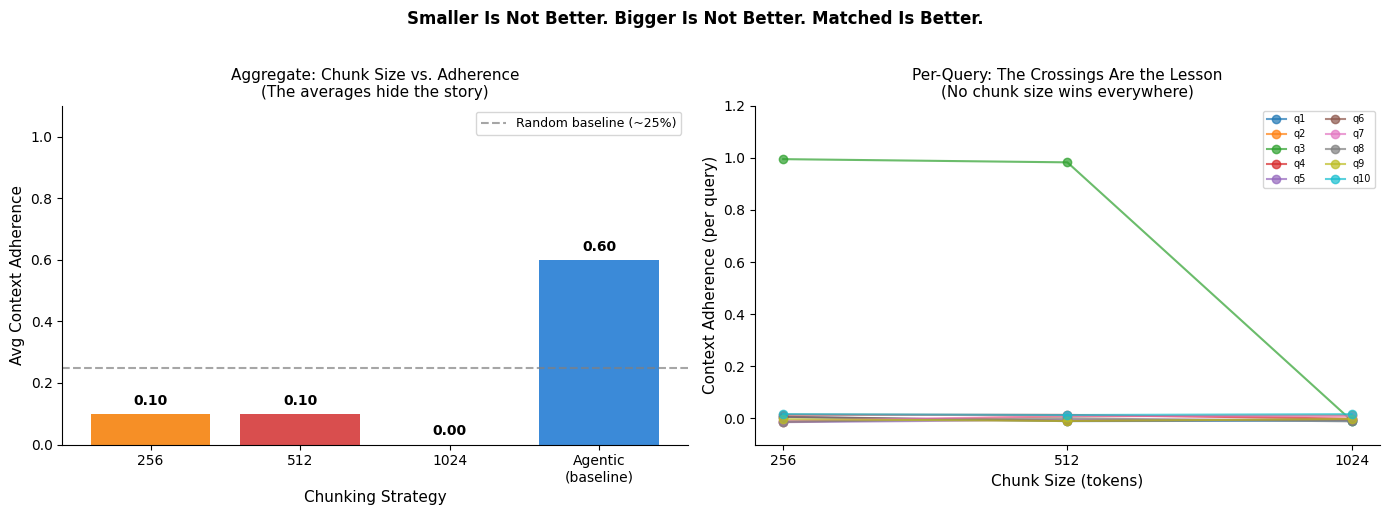

Figure 7 saved.


In [7]:
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)

# Left panel: aggregate bars
ax1 = fig.add_subplot(gs[0])
chunk_labels = [str(cs) for cs in CHUNK_SIZES] + ['Agentic\n(baseline)']
adherence_vals = [sensitivity_results[cs]['avg_adherence'] for cs in CHUNK_SIZES]
adherence_vals.append(prior_results['strategy_b']['avg_adherence'])

colors = ['#f57c00', '#d32f2f', '#7b1fa2', '#1976d2']
bars = ax1.bar(chunk_labels, adherence_vals, color=colors, alpha=0.85)

ax1.axhline(y=0.25, color='gray', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Random baseline (~25%)')
ax1.set_xlabel('Chunking Strategy', fontsize=11)
ax1.set_ylabel('Avg Context Adherence', fontsize=11)
ax1.set_title('Aggregate: Chunk Size vs. Adherence\n(The averages hide the story)', fontsize=11)
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.02,
             f'{h:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right panel: per-query lines (the crossings)
ax2 = fig.add_subplot(gs[1])
query_ids = [r["query_id"] for r in sensitivity_results[256]["per_query"]]

for i, q_id in enumerate(query_ids):
    vals = [sensitivity_results[cs]["per_query"][i]["adherence"] for cs in CHUNK_SIZES]
    # Add small jitter so overlapping lines are visible
    jitter = np.random.uniform(-0.02, 0.02, len(CHUNK_SIZES))
    ax2.plot([str(cs) for cs in CHUNK_SIZES],
             [v + j for v, j in zip(vals, jitter)],
             marker='o', linewidth=1.5, alpha=0.7, label=q_id)

ax2.set_xlabel('Chunk Size (tokens)', fontsize=11)
ax2.set_ylabel('Context Adherence (per query)', fontsize=11)
ax2.set_title('Per-Query: The Crossings Are the Lesson\n(No chunk size wins everywhere)', fontsize=11)
ax2.set_ylim(-0.1, 1.2)
ax2.legend(fontsize=7, loc='upper right', ncol=2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Smaller Is Not Better. Bigger Is Not Better. Matched Is Better.',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs(f'{BASE}/figures', exist_ok=True)
plt.savefig(f'{BASE}/figures/figure_7_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

In [8]:
print("="*60)
print("THE ARCHITECTURAL LESSON")
print("="*60)

best_cs = max(CHUNK_SIZES, key=lambda cs: sensitivity_results[cs]['avg_adherence'])
best_adherence = sensitivity_results[best_cs]['avg_adherence']
agentic_adherence = prior_results['strategy_b']['avg_adherence']
gap = agentic_adherence - best_adherence

print(f"\nBest fixed-size chunk size: {best_cs} tokens")
print(f"Best fixed-size adherence: {best_adherence:.2f}")
print(f"Agentic chunking adherence: {agentic_adherence:.2f}")
print(f"Gap that tuning cannot close: {gap:.2f}")
print(f"\nThe interaction is between two distributions:")
print(f"  - Chunk size: the parameter you control")
print(f"  - Holding length: a property of your documents")
print(f"\nThere is no chunk size where both are optimized.")
print(f"Smaller isn't better. Bigger isn't better. Matched is better.")
print(f"The averages cancel out. The failures don't.")
print(f"\nTuning the wrong variable doesn't converge.")
print(f"That assumption is what this exercise is designed to destroy.")

THE ARCHITECTURAL LESSON

Best fixed-size chunk size: 256 tokens
Best fixed-size adherence: 0.10
Agentic chunking adherence: 0.60
Gap that tuning cannot close: 0.50

The interaction is between two distributions:
  - Chunk size: the parameter you control
  - Holding length: a property of your documents

There is no chunk size where both are optimized.
Smaller isn't better. Bigger isn't better. Matched is better.
The averages cancel out. The failures don't.

Tuning the wrong variable doesn't converge.
That assumption is what this exercise is designed to destroy.


In [9]:
with open(f'{BASE}/results/results_04.json', 'w') as f:
    json.dump({
        "chunk_sizes_tested": CHUNK_SIZES,
        "results": {
            str(cs): {
                "avg_adherence": sensitivity_results[cs]["avg_adherence"],
                "avg_similarity": sensitivity_results[cs]["avg_similarity"]
            } for cs in CHUNK_SIZES
        },
        "agentic_baseline": prior_results['strategy_b']['avg_adherence'],
        "gap_tuning_cannot_close": float(gap)
    }, f, indent=2)

print("Results saved to results/results_04.json")
print("\nStatus: READY TO PROCEED TO NOTEBOOK 05")

Results saved to results/results_04.json

Status: READY TO PROCEED TO NOTEBOOK 05
